# 🚀 GPU Benchmark
Benchmark matmul FP16 avec Tensor Cores. Mesure les TFLOPS réels par itération, le pic de performance et la moyenne stabilisée.

In [5]:
import torch
import time
import os

# ── Activer Tensor Cores (TF32 + FP16) ───────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
dtype = torch.float16

# ── Détection GPU ─────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA non disponible — branchez un GPU !")

device = torch.device("cuda")
props  = torch.cuda.get_device_properties(0)
gpu_name   = props.name
total_vram = props.total_memory / 1e9

print(f"GPU      : {gpu_name}")
print(f"VRAM     : {total_vram:.2f} Go")
print(f"SM count : {props.multi_processor_count}")

GPU      : NVIDIA GeForce RTX 4070 Ti
VRAM     : 12.88 Go
SM count : 60


In [6]:
# ── Paramètres ────────────────────────────────────────────────────────────────
MATRIX_SIZE  = 16_000   # Taille N des matrices N×N
WARMUP_ITERS = 3        # Itérations de chauffe (non comptées)
BENCH_ITERS  = 10       # Itérations de mesure

def get_gpu_util() -> float:
    """Utilisation GPU via nvidia-smi (%), retourne NaN si indisponible."""
    try:
        out = os.popen("nvidia-smi --query-gpu=utilization.gpu --format=csv,noheader,nounits").read().strip()
        return float(out)
    except Exception:
        return float("nan")

def measure_tflops(A: torch.Tensor, B: torch.Tensor) -> float:
    """Mesure les TFLOPS d'une multiplication A × B via CUDA Events."""
    n = A.shape[0]
    t0 = torch.cuda.Event(enable_timing=True)
    t1 = torch.cuda.Event(enable_timing=True)
    t0.record(stream=torch.cuda.current_stream())
    _ = torch.matmul(A, B)
    t1.record(stream=torch.cuda.current_stream())
    torch.cuda.synchronize()
    elapsed_s = t0.elapsed_time(t1) / 1e3          # ms → s
    flops = 2 * n ** 3                              # opérations flottantes
    return flops / elapsed_s / 1e12                 # → TFLOPS

def run_matmul_benchmark(dtype):
    print(f"\n{'='*68}")
    print(f"  Début du benchmark pour dtype: {dtype}")
    print(f"{'-'*68}")

    # ── Allocation des matrices ────────────────────────────────────────────────────
    print(f"Allocation de 2 matrices {MATRIX_SIZE}×{MATRIX_SIZE} ({dtype}) sur {device}…")
    A = torch.randn(MATRIX_SIZE, MATRIX_SIZE, device=device, dtype=dtype)
    B = torch.randn(MATRIX_SIZE, MATRIX_SIZE, device=device, dtype=dtype)
    vram_used = torch.cuda.memory_allocated(0) / 1e9
    vram_rsvd = torch.cuda.memory_reserved(0) / 1e9
    print(f"VRAM utilisée : {vram_used:.2f} Go allouée / {vram_rsvd:.2f} Go réservée")

    # ── Warmup ────────────────────────────────────────────────────────────────────
    print(f"\nChauffe ({WARMUP_ITERS} itérations)…")
    for _ in range(WARMUP_ITERS):
        _ = torch.matmul(A, B)
    torch.cuda.synchronize()
    print("Warmup terminé.")

    # ── Benchmark ─────────────────────────────────────────────────────────────────
    print(f"\n{'─'*68}")
    print(f"{'Iter':>5}  {'TFLOPS':>8}  {'GPU Util':>9}  {'VRAM alloc':>11}  {'VRAM rsvd':>10}")
    print(f"{'─'*68}")

    tflops_history = []
    start_total = time.perf_counter()

    for it in range(1, BENCH_ITERS + 1):
        tflops = measure_tflops(A, B)
        tflops_history.append(tflops)

        util  = get_gpu_util()
        valloc = torch.cuda.memory_allocated(0) / 1e9
        vrsvd  = torch.cuda.memory_reserved(0) / 1e9

        util_str = f"{util:.0f}%" if not (util != util) else "N/A"
        print(f"{it:>5}  {tflops:>8.2f}  {util_str:>9}  {valloc:>9.2f} Go  {vrsvd:>8.2f} Go")

    total_elapsed = time.perf_counter() - start_total
    print(f"{'─'*68}")

    # ── Statistiques ──────────────────────────────────────────────────────────────
    peak_tflops = max(tflops_history)
    mean_tflops = sum(tflops_history) / len(tflops_history)
    # Exclure la 1re itération (souvent froide) pour la moyenne stabilisée
    stable_mean = sum(tflops_history[1:]) / (len(tflops_history) - 1 if len(tflops_history) > 1 else 1) 

    print(f"\n{'═'*68}")
    print(f"  Benchmark terminé en {total_elapsed:.2f}s ({BENCH_ITERS} itérations)")
    print(f"  Matrice : {MATRIX_SIZE}×{MATRIX_SIZE} {dtype}")
    print(f"{'-'*68}")
    print(f"  TFLOPS peak       : {peak_tflops:.2f}")
    print(f"  TFLOPS moyen      : {mean_tflops:.2f}")
    print(f"  TFLOPS stabilisé  : {stable_mean:.2f}  (iter 2-{BENCH_ITERS})")
    print(f"{'-'*68}")

    return {
        "dtype": dtype,
        "tflops_history": tflops_history,
        "peak_tflops": peak_tflops,
        "mean_tflops": mean_tflops,
        "stable_mean": stable_mean,
        "total_elapsed": total_elapsed,
        "matrix_size": MATRIX_SIZE,
        "gpu_name": gpu_name
    }

# Run benchmarks for different dtypes
benchmark_results = {}
for current_dtype in [torch.float16, torch.float32, torch.float64]:
    result = run_matmul_benchmark(current_dtype)
    benchmark_results[str(current_dtype)] = result

print("\nRécapitulatif des benchmarks:")
for dtype_str, res in benchmark_results.items():
    print(f"  {dtype_str}: Peak {res['peak_tflops']:.2f} TFLOPS, Stable Mean {res['stable_mean']:.2f} TFLOPS")


  Début du benchmark pour dtype: torch.float16
--------------------------------------------------------------------
Allocation de 2 matrices 16000×16000 (torch.float16) sur cuda…
VRAM utilisée : 2.57 Go allouée / 2.59 Go réservée

Chauffe (3 itérations)…
Warmup terminé.

────────────────────────────────────────────────────────────────────
 Iter    TFLOPS   GPU Util   VRAM alloc   VRAM rsvd
────────────────────────────────────────────────────────────────────
    1     70.97        97%       3.08 Go      3.62 Go
    2     77.98        97%       3.08 Go      3.62 Go
    3     78.44       100%       3.08 Go      3.62 Go
    4     79.03       100%       3.08 Go      3.62 Go
    5     77.97       100%       3.08 Go      3.62 Go
    6     77.32        39%       3.08 Go      3.62 Go
    7     78.24        39%       3.08 Go      3.62 Go
    8     78.69        38%       3.08 Go      3.62 Go
    9     78.31        38%       3.08 Go      3.62 Go
   10     77.02        95%       3.08 Go      3.62 

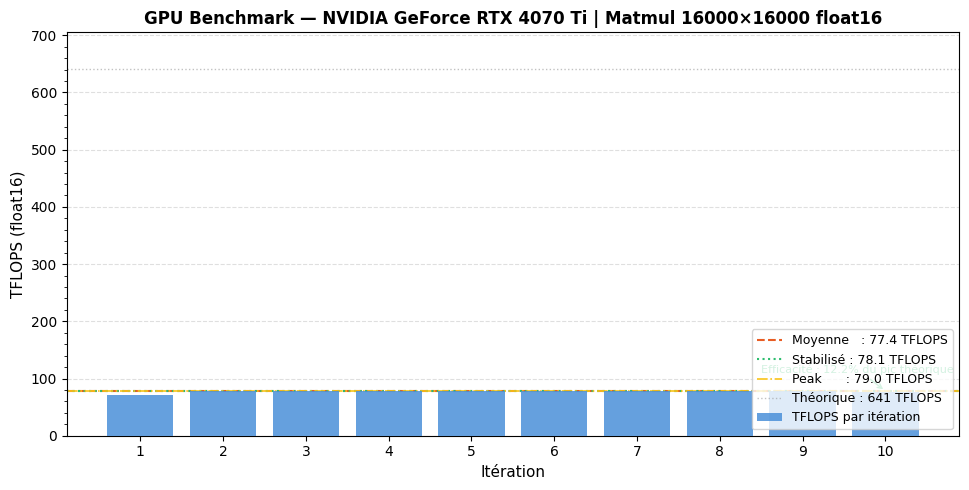

Graphique sauvegardé → benchmark_result_float16.png


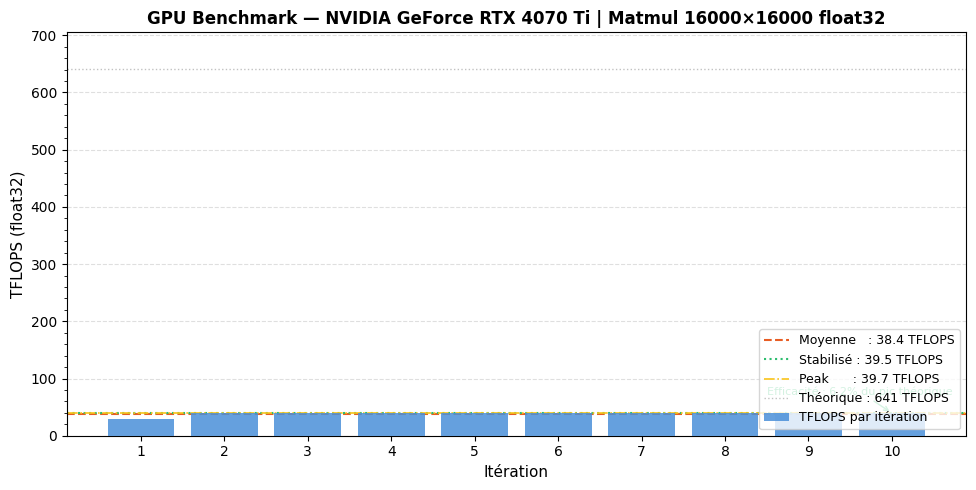

Graphique sauvegardé → benchmark_result_float32.png


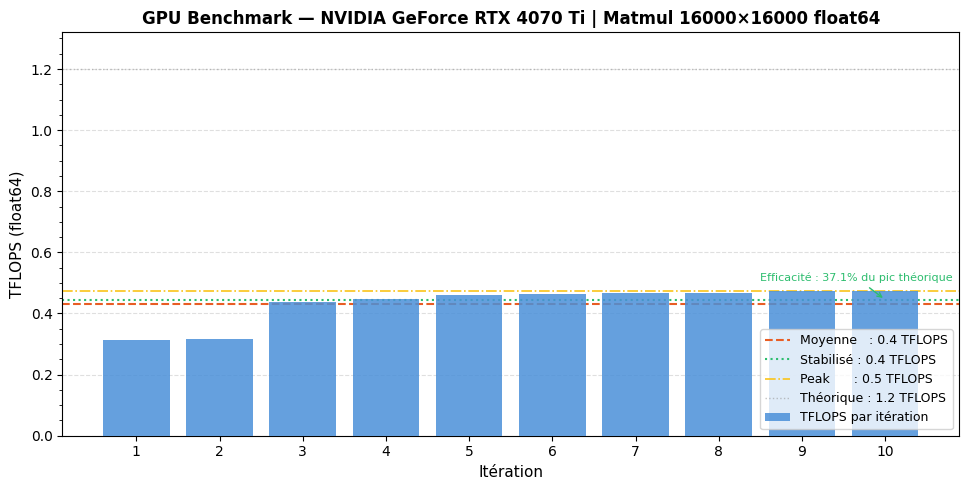

Graphique sauvegardé → benchmark_result_float64.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Theoretical TFLOPS values for RTX 4070 Ti (Ada Lovelace architecture)
# FP16 with Tensor Cores: 641 TFLOPS
# FP32 (TF32 with Tensor Cores): Also ~641 TFLOPS (TF32 throughput is similar to FP16 on Ada Lovelace)
# FP64: Very limited on consumer cards, typically low (e.g., ~1/32 to 1/64 of FP32 non-Tensor Core perf)
THEORETICAL_PEAKS = {
    "torch.float16": 641,
    "torch.float32": 641, # With TF32 enabled, FP32 matmul uses Tensor Cores for performance close to FP16.
    "torch.float64": 1.2  # Approximate for consumer GPUs with limited FP64 hardware
}

for dtype_str, res in benchmark_results.items():
    tflops_history = res["tflops_history"]
    peak_tflops    = res["peak_tflops"]
    mean_tflops    = res["mean_tflops"]
    stable_mean    = res["stable_mean"]
    matrix_size    = res["matrix_size"]
    gpu_name       = res["gpu_name"]
    current_dtype  = res["dtype"] # This is the torch.dtype object

    fig, ax = plt.subplots(figsize=(10, 5))

    iters = list(range(1, len(tflops_history) + 1))

    ax.bar(iters, tflops_history, color="#4A90D9", alpha=0.85, zorder=3, label="TFLOPS par itération")
    ax.axhline(mean_tflops,   color="#E85D24", linestyle="--", linewidth=1.5, label=f"Moyenne   : {mean_tflops:.1f} TFLOPS")
    ax.axhline(stable_mean,   color="#2DBD6E", linestyle=":",  linewidth=1.5, label=f"Stabilisé : {stable_mean:.1f} TFLOPS")
    ax.axhline(peak_tflops,   color="#FAC41A", linestyle="-.", linewidth=1.2, label=f"Peak      : {peak_tflops:.1f} TFLOPS")

    theoretical_peak_for_dtype = THEORETICAL_PEAKS.get(dtype_str, 0) 

    if theoretical_peak_for_dtype > 0:
        ax.axhline(theoretical_peak_for_dtype, color="#999", linestyle=":", linewidth=1, alpha=0.6, label=f"Théorique : {theoretical_peak_for_dtype} TFLOPS")

    ax.set_xlabel("Itération", fontsize=11)
    ax.set_ylabel(f"TFLOPS ({str(current_dtype).split('.')[-1]})", fontsize=11)
    ax.set_title(f"GPU Benchmark — {gpu_name} | Matmul {matrix_size}×{matrix_size} {str(current_dtype).split('.')[-1]}", fontsize=12, fontweight="bold")
    ax.set_xticks(iters)
    ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.legend(fontsize=9, loc="lower right")

    # Set y-axis limit dynamically
    max_val_for_ylim = max(peak_tflops, theoretical_peak_for_dtype) if theoretical_peak_for_dtype > 0 else peak_tflops
    ax.set_ylim(0, max_val_for_ylim * 1.1)

    # Annotation efficacité
    if theoretical_peak_for_dtype > 0 and stable_mean > 0: # Ensure stable_mean is not zero to avoid division by zero
        efficiency = stable_mean / theoretical_peak_for_dtype * 100
        ax.annotate(
            f"Efficacité : {efficiency:.1f}% du pic théorique",
            xy=(len(iters), stable_mean),
            xytext=(len(iters) - 1.5, stable_mean + (max_val_for_ylim * 0.05)),
            fontsize=8, color="#2DBD6E",
            arrowprops=dict(arrowstyle="->", color="#2DBD6E", lw=1)
        )

    fig.tight_layout()
    filename = f"benchmark_result_{str(current_dtype).split('.')[-1]}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Graphique sauvegardé → {filename}")